In [1]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn

In [264]:
# some tidying of the data 

books = pd.read_csv('../../data/data_with_author_and_awards.csv')

# apply data cleaning stuff 

%run ../../data/tidy_book_tags.ipynb # to get clean_filter_tags function

%run ../../data/tidy_publisher.ipynb # to get publisher_tidy function

books['first_publisher'] = publisher_tidy(books['first_publisher'])

books['tags'] = clean_filter_tags(books['tags'])

# combine awards into one target column

books['target'] = books['hugo'] | books['locus']

/var/folders/bt/8s6v7ngs6m93f2x58bpj1zl00000gn/T/ipykernel_46754/1892821212.py:3: DtypeWarning: Columns (0: isbn) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('../../data/data_with_author_and_awards.csv')


In [265]:
# do not want books from before awards
books = books[books['release_year'] >= 1970]

In [266]:
books.head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,target
4100,689509.0,The Simultaneous Man,Ralph Blum,1970,1970-03-00,bantambooks,1932.0,"Los Angeles, California, USA",0553058789,NaN,...,False,03,38,0,0,False,False,USA,Central/North America,False
4101,2297062.0,The Three Straw Men,August Derleth,1970,1970-11-00,Other,1909.0,"Sauk City, Wisconsin, USA",0876860080,NaN,...,False,11,61,0,0,False,False,USA,Central/North America,False
4102,2499270.0,Witch's Suckling,Gimone Hall,1970,1970-09-00,manorbooks,NaN,NaN,NaN,NaN,...,False,09,Unknown,0,0,False,False,Unknown,Unknown,False
4103,531585.0,The Sorcerer's Skull,David Mason,1970,1970-00-00,lancerbooks,1924.0,NaN,1587150638,NaN,...,False,Unknown,46,0,0,False,False,Unknown,Unknown,False
4104,1984860.0,Bantan and the Mermaids,Maurice B. Gardner,1970,1970-00-00,Other,1905.0,"Portland, Maine, USA",NaN,NaN,...,False,Unknown,65,0,0,False,False,USA,Central/North America,False


<Axes: >

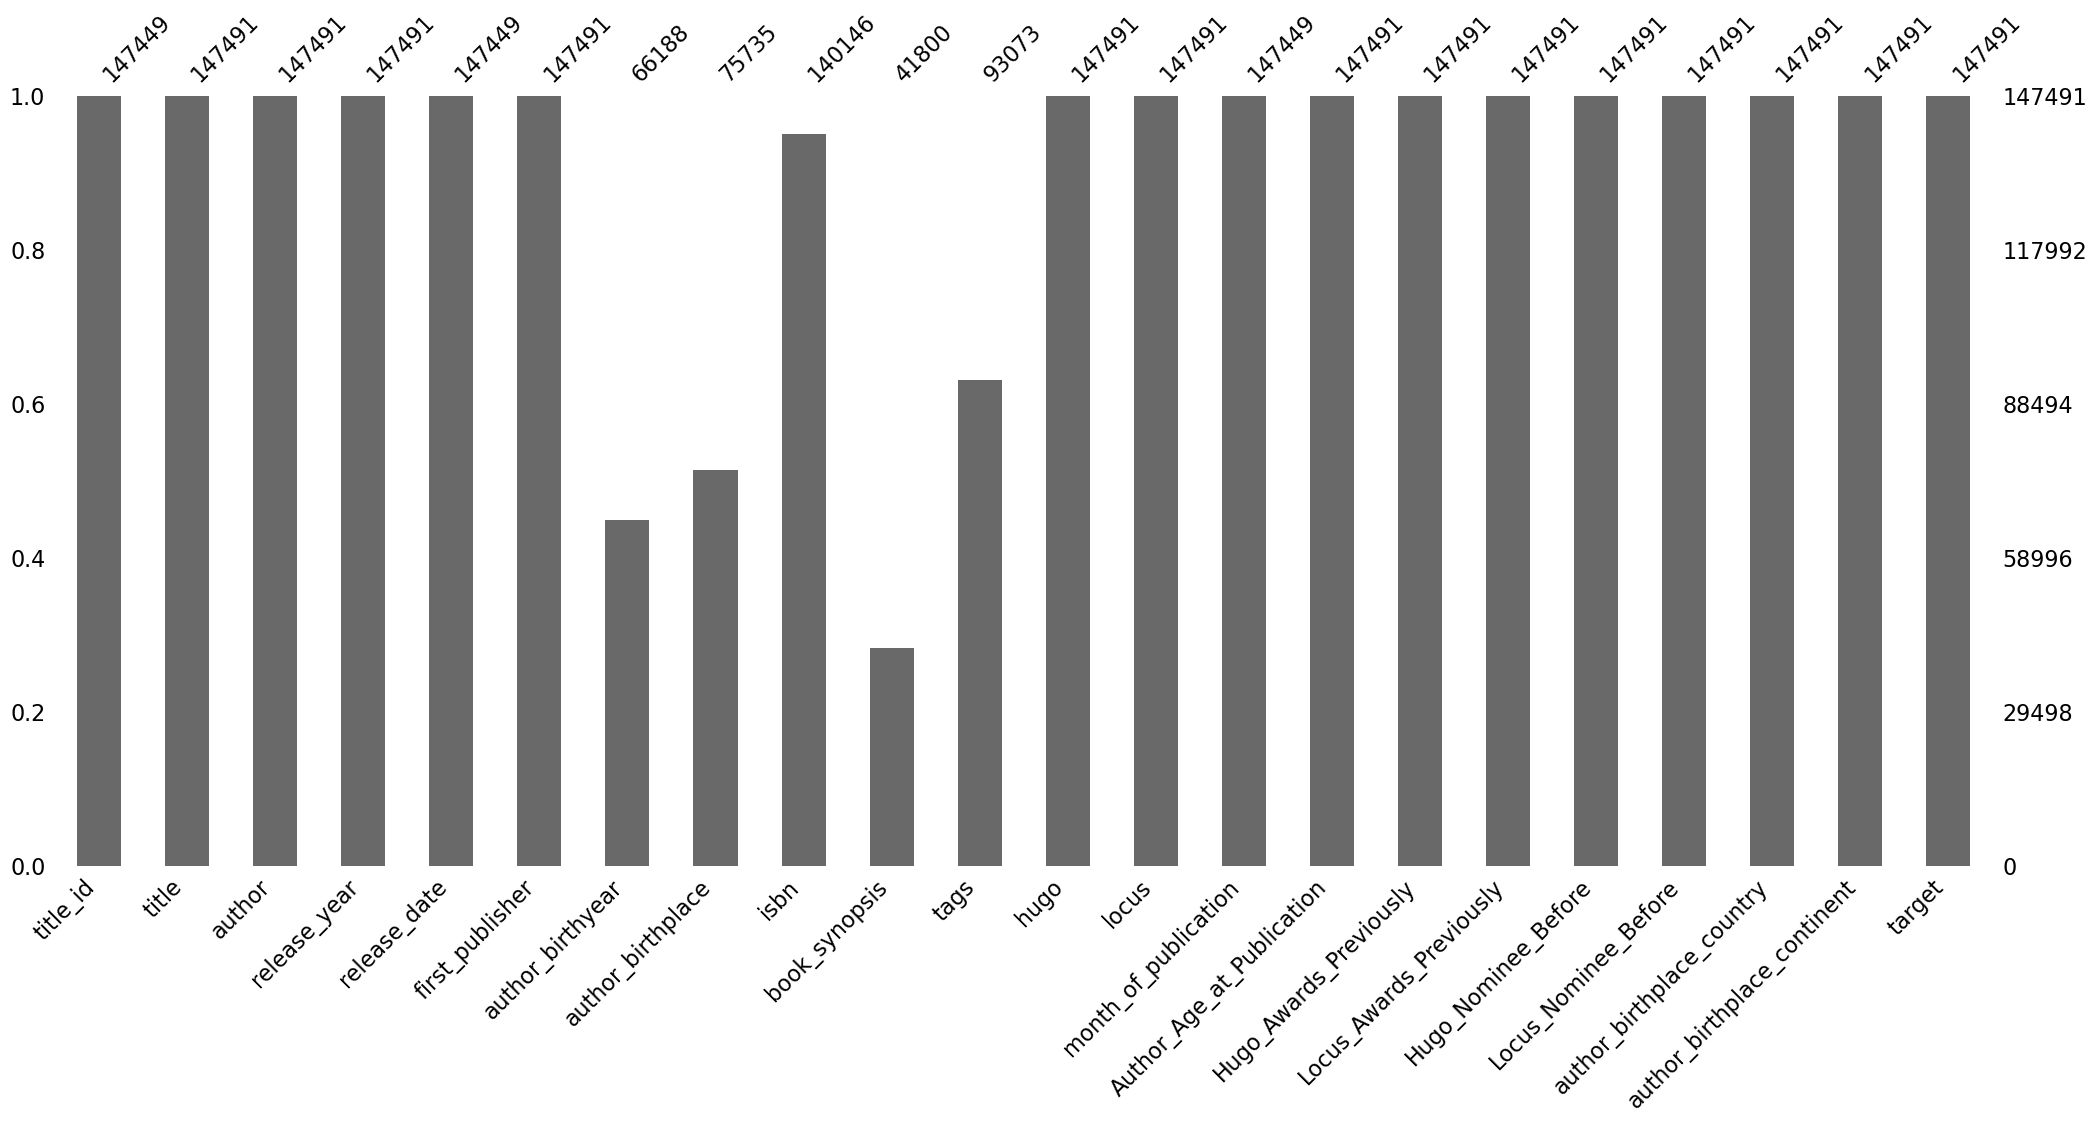

In [267]:
msno.bar(books)

In [268]:
# MISSINGNESS:
# for the sake of this notebook, we shall:
# - omit book synopses, title_id, isbn, release_date (captured in month), author_birthyear, author_birthplace (captured in country and continent)
# - and turn all empty tags into empty string ""

books = books.drop(["title_id", "isbn", "release_date", "author_birthyear", "book_synopsis", "author_birthplace"], axis=1)


In [269]:
type(books['tags'][4100])

float

In [270]:
books['tags'] = books['tags'].apply(lambda x: '' if isinstance(x, float) else x)

<Axes: >

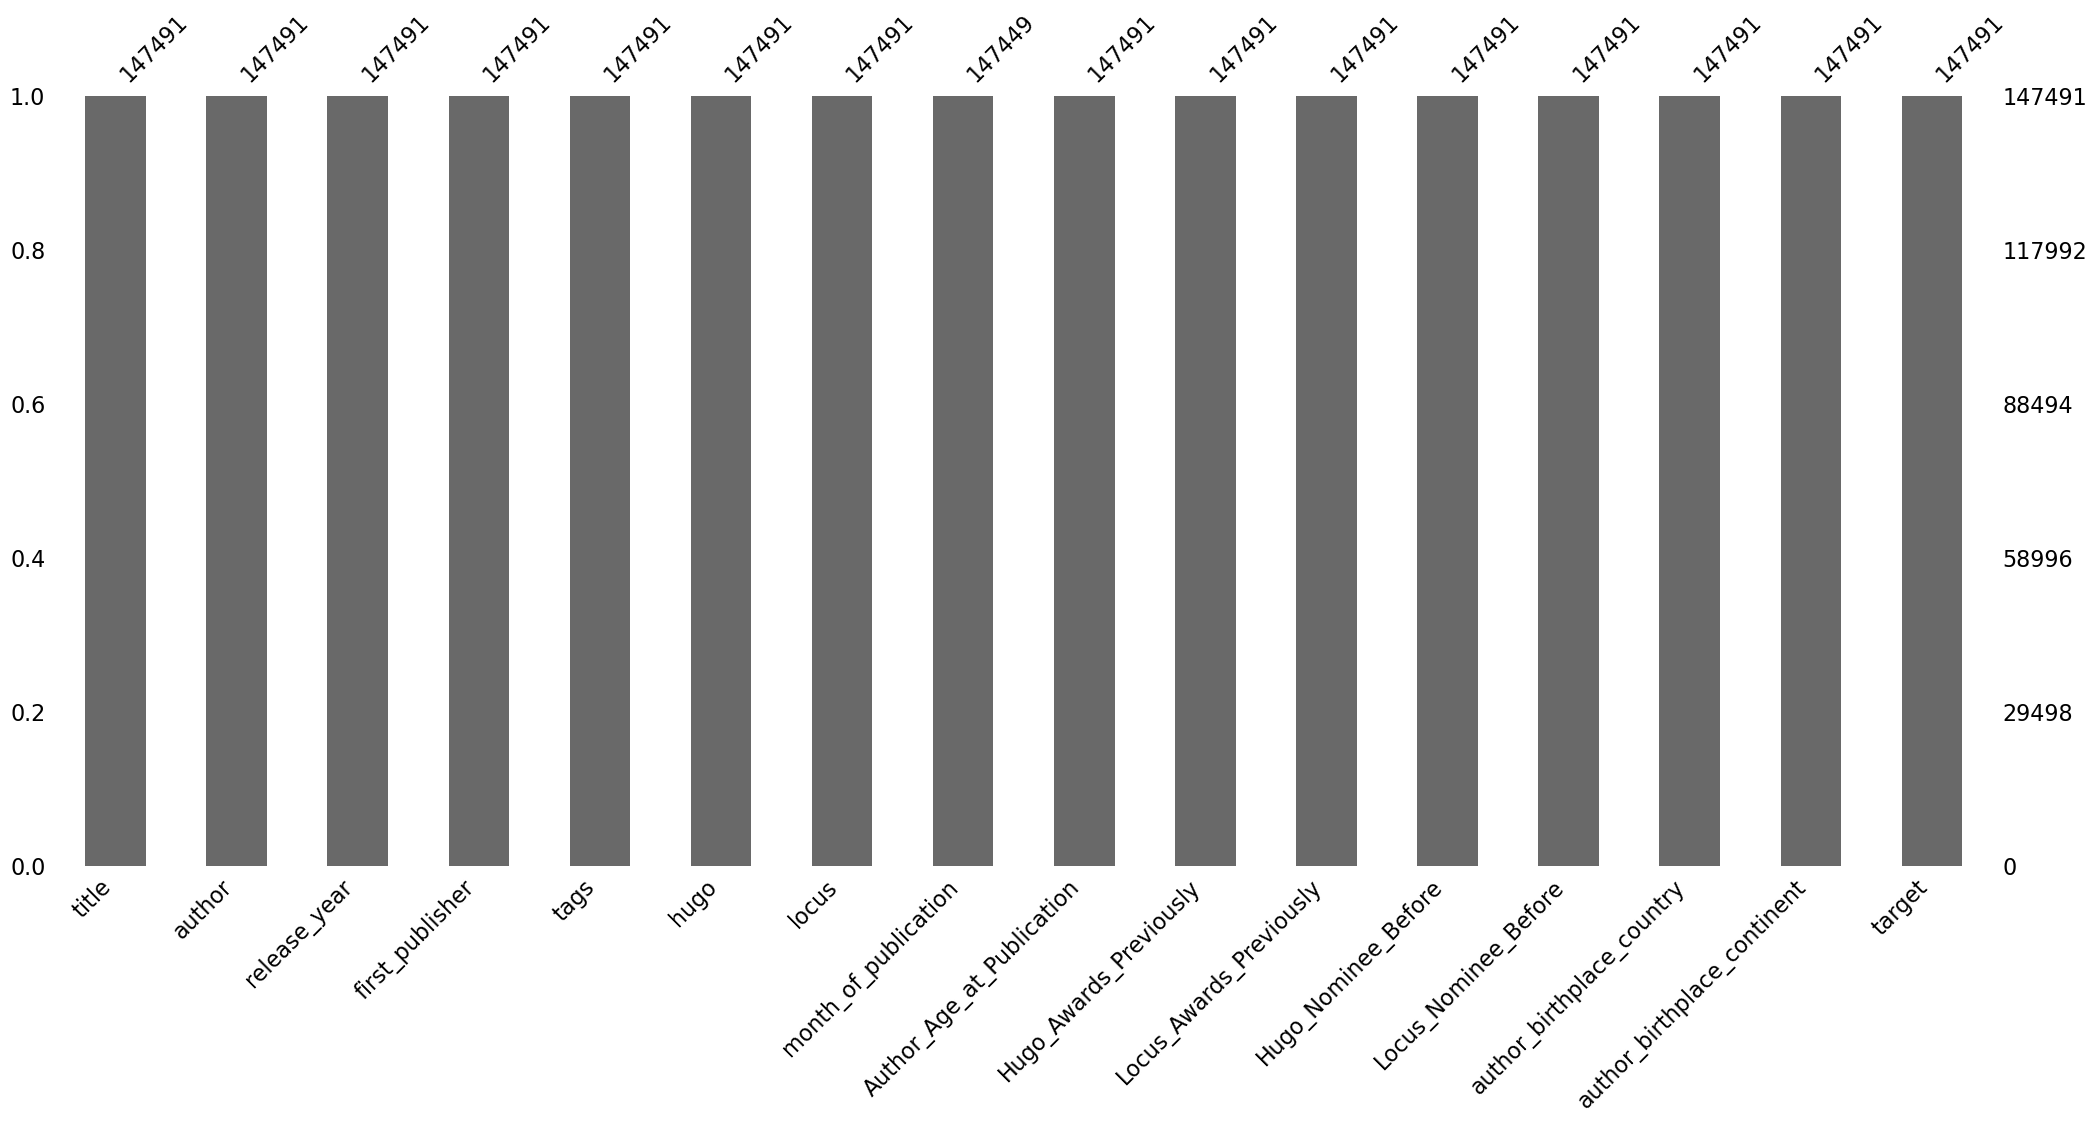

In [271]:
msno.bar(books)

In [272]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 147491 entries, 4100 to 151590
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   title                        147491 non-null  str   
 1   author                       147491 non-null  str   
 2   release_year                 147491 non-null  int64 
 3   first_publisher              147491 non-null  str   
 4   tags                         147491 non-null  object
 5   hugo                         147491 non-null  bool  
 6   locus                        147491 non-null  bool  
 7   month_of_publication         147449 non-null  str   
 8   Author_Age_at_Publication    147491 non-null  str   
 9   Hugo_Awards_Previously       147491 non-null  int64 
 10  Locus_Awards_Previously      147491 non-null  int64 
 11  Hugo_Nominee_Before          147491 non-null  bool  
 12  Locus_Nominee_Before         147491 non-null  bool  
 13  author_birthplace_coun

In [273]:
books_tt['author_birthplace_country'].value_counts()

author_birthplace_country
USA                   22490
Unknown               12257
UK                     9023
Canada                 1207
Australia               757
                      ...  
Dominican Republic        1
Croatia                   1
Cyprus                    1
East Indies               1
Colombia                  1
Name: count, Length: 101, dtype: int64

In [280]:
books['Author_Age_at_Publication'] = pd.to_numeric(
    books['Author_Age_at_Publication'], errors='coerce'
)


In [364]:
books_tt = books[(books['release_year'] >= 1970) & (books['release_year'] < 2010)]
books_val = books[(books['release_year'] >= 2010) & (books['release_year'] < 2015)]

books_test = books[(books['release_year'] >= 2015)]


In [365]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 147491 entries, 4100 to 151590
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   title                        147491 non-null  str    
 1   author                       147491 non-null  str    
 2   release_year                 147491 non-null  int64  
 3   first_publisher              147491 non-null  str    
 4   tags                         147491 non-null  object 
 5   hugo                         147491 non-null  bool   
 6   locus                        147491 non-null  bool   
 7   month_of_publication         147449 non-null  str    
 8   Author_Age_at_Publication    66188 non-null   float64
 9   Hugo_Awards_Previously       147491 non-null  int64  
 10  Locus_Awards_Previously      147491 non-null  int64  
 11  Hugo_Nominee_Before          147491 non-null  bool   
 12  Locus_Nominee_Before         147491 non-null  bool   
 13  author_

##### Preprocessing of columns

In [366]:
#  0   title                        147491 non-null  str   -- not used
#  1   author                       147491 non-null  str   -- not used
#  2   release_year                 147491 non-null  int64 -- used (for normalization per yar)
#  3   first_publisher              147491 non-null  str   -- use (catergorical)
#  4   tags                         147491 non-null  object -- use (multilabel binarize)
#  5   hugo                         147491 non-null  bool  -- not used (use combine target)
#  6   locus                        147491 non-null  bool  -- not used (use combine target)
#  7   month_of_publication         147449 non-null  str   -- use (categorical)
#  8   Author_Age_at_Publication    147491 non-null  int64   -- use (numerical)
#  9   Hugo_Awards_Previously       147491 non-null  int64 -- use (numerical)
#  10  Locus_Awards_Previously      147491 non-null  int64 -- use (numerical)
#  11  Hugo_Nominee_Before          147491 non-null  bool  -- use (numerical)
#  12  Locus_Nominee_Before         147491 non-null  bool  -- use (numerical)
#  13  author_birthplace_country    147491 non-null  str   -- use (categorical) 
#  14  author_birthplace_continent  147491 non-null  str   -- use (categorical)
#  15  target                       147491 non-null  bool  -- target (categorical or numerical)

In [367]:
numerical_features = ["Hugo_Awards_Previously", "Locus_Awards_Previously"]
categorical_features = ["first_publisher", "month_of_publication", "author_birthplace_country", "author_birthplace_continent"]
mlb_features = ["tags"]
bool_features = ["Hugo_Nominee_Before", "Locus_Nominee_Before"]

In [368]:
for col in numerical_features:
    books_tt[col] = books_tt[col].astype(float)

In [369]:
## do multilabel binarizer of tags outside preprocessing. 
from sklearn.preprocessing import MultiLabelBinarizer

tag_labeler = MultiLabelBinarizer()
tag_labels = tag_labeler.fit_transform(books_tt['tags'].fillna(''))

# save as dataframe
tag_dataframe = pd.DataFrame(
    tag_labels,
    columns = ["tag_{}".format(tag) for tag in tag_labeler.classes_],
    index=books_tt.index
)

# concatenate to training dataframe
books_tt = pd.concat([books_tt, tag_dataframe], axis=1)

In [411]:
# calculate dot product with other books' genre tags
from sklearn.metrics.pairwise import cosine_similarity

def get_similarity_list(df):
    for year, data in df.groupby('release_year'):
        tag_data = data[list(tag_dataframe.columns)]
        similarity = cosine_similarity(tag_data)
        book_mean_similarity = np.mean(cosine_similarity(tag_data), axis=0)
    return book_mean_similarity

In [370]:
books_tt.info()

<class 'pandas.DataFrame'>
RangeIndex: 47984 entries, 4100 to 52083
Columns: 132 entries, title to tag_zombi
dtypes: bool(5), float64(3), int64(117), object(1), str(6)
memory usage: 49.6+ MB


for some features, we want to normalize against the rest of the cohort.

for numerical features, this is z-score normalization, through StandardScaler().

but, we want to normalize within each year, not across all years.

let's try to build a custom transformer with guidance from https://www.andrewvillazon.com/custom-scikit-learn-transformers/


In [478]:
from numpy.random import randint
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

class YearByYearStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, year_column='year', scale_columns=None):
        self.scale_columns = scale_columns
        self.year_column = year_column

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        # apply standard scaler to each year group by group
        for year, data in X.groupby(by=self.year_column):
            imputer = SimpleImputer(strategy='mean')
            X.loc[data.index, self.scale_columns] = imputer.fit_transform(data[self.scale_columns])

            scaler = StandardScaler()
            # print(X.loc[data.index, 'Locus_Awards_Previously'].mean(), X.loc[data.index, 'Locus_Awards_Previously'].std())
            X.loc[data.index, self.scale_columns] = scaler.fit_transform(data[self.scale_columns])#pd.DataFrame(scaler.fit_transform(data[self.scale_columns]))
            # print(X.loc[data.index, self.scale_columns])
        return X#.drop(columns=[self.year_column])
    
class YearlyGenreTagScaler(BaseEstimator, TransformerMixin):
    def __init__(self, year_column='year', tag_columns=None):
        self.tag_columns = tag_columns
        self.year_column = year_column

    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X, y=None):
        X = X.copy()

        similarity_series = pd.Series(dtype=float, index=X.index)

        for year, data in X.groupby(by=self.year_column):
            tag_data = data[self.tag_columns]
            similarity = cosine_similarity(tag_data)
            book_mean_similarity = np.mean(similarity, axis=0)
            similarity_series.loc[data.index] = book_mean_similarity

        X['cohort_similiarity'] = similarity_series
        return X.drop(columns=[self.year_column])


In [479]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

tags_pipeline = Pipeline(
    steps=[
        ('similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'))
    ]
)

feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('onehot', categorical_pipeline, categorical_features),
        ('tag_similarity', tags_pipeline, list(tag_dataframe.columns) + ['release_year'])
    ],
    remainder='passthrough'
)

In [480]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn import svm
from sklearn.base import clone

models = {
    'dummy_mostfrequent': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='most_frequent'))
    ]
    ),
    'dummy_stratified': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='stratified'))
    ]
    ),
    'simple_classifier': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000))
    ]
    ),
    'simple_classifier_balanced': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]
    ),
        'svc': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('svc', svm.SVC())
    ]
    ),

            'decision-tree': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('tree', tree.DecisionTreeClassifier())
    ]
    ),

}

In [481]:
scores

{'dummy_mostfrequent': 0.0,
 'dummy_stratified': 0.008896797153024912,
 'simple_classifier': 0.4349775784753363,
 'simple_classifier_balanced': 0.28197226502311246}

In [482]:
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year']


for name, model in models.items():
    print(name)
    model.fit(books_tt[features], books_tt['target'])

dummy_mostfrequent
dummy_stratified
simple_classifier


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


simple_classifier_balanced


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


svc
decision-tree


In [483]:
from sklearn.utils.validation import check_is_fitted

for name, model in models.items():
    print(f"Checking {name}...")
    try:
        # Check the top-level pipeline
        print("  Pipeline fitted:", hasattr(model, "classes_") or hasattr(model, "estimator_"))
        
        # Check the preprocessing step specifically
        preprocess_step = model.named_steps['preprocess']
        print("  Preprocess fitted:", hasattr(preprocess_step, "transformers_"))
        
    except Exception as e:
        print(f"  Error checking state: {e}")

Checking dummy_mostfrequent...
  Pipeline fitted: True
  Preprocess fitted: True
Checking dummy_stratified...
  Pipeline fitted: True
  Preprocess fitted: True
Checking simple_classifier...
  Pipeline fitted: True
  Preprocess fitted: True
Checking simple_classifier_balanced...
  Pipeline fitted: True
  Preprocess fitted: True
Checking svc...
  Pipeline fitted: True
  Preprocess fitted: True
Checking decision-tree...
  Pipeline fitted: True
  Preprocess fitted: True


In [484]:
books_val = books[(books['release_year'] >= 2010) & (books['release_year'] < 2015)]

tags_binarized = tag_labeler.transform(books_val['tags'].fillna(''))
tags_df = pd.DataFrame(
tags_binarized, 
columns=[f"tag_{c}" for c in tag_labeler.classes_],
index=books_val.index
)
books_val = pd.concat([books_val, tags_df], axis=1)

additional_scores = {}
preds = {}

for col in numerical_features:
    books_val[col] = books_val[col].astype(float)

for name, model in models.items():
    print(name)

    ypred = model.predict(books_val[features])

    additional_scores[name]= f1_score(books_val['target'], ypred)
    preds[name] = ypred

dummy_mostfrequent


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['standalon', 'supervillain'] will be ignored
  warnings.warn(


dummy_stratified
simple_classifier
simple_classifier_balanced
svc
decision-tree


In [485]:
additional_scores

{'dummy_mostfrequent': 0.0,
 'dummy_stratified': 0.010676156583629894,
 'simple_classifier': 0.4247787610619469,
 'simple_classifier_balanced': 0.2809415337889142,
 'svc': 0.0,
 'decision-tree': 0.46335697399527187}

In [486]:
{'dummy_mostfrequent': 0.0,
 'dummy_stratified': 0.015584415584415584,
 'simple_classifier': 0.3421686746987952,
 'simple_classifier_balanced': 0.3047945205479452,
 'svc': 0.0,
 'decision-tree': 0.3617886178861789}


{'dummy_mostfrequent': 0.0,
 'dummy_stratified': 0.015584415584415584,
 'simple_classifier': 0.3421686746987952,
 'simple_classifier_balanced': 0.3047945205479452,
 'svc': 0.0,
 'decision-tree': 0.3617886178861789}

In [474]:
for name, model in models.items():
    matrix = confusion_matrix(books_val['target'], preds[model], normalize='true')
    print("--- name ---")
    print(matrix)

KeyError: Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical_scaling',
                                                  YearByYearStandardScaler(scale_columns=['Hugo_Awards_Previously',
                                                                                          'Locus_Awards_Previously'],
                                                                           year_column='release_year'),
                                                  ['Hugo_Awards_Previously',
                                                   'Locus_Awards_Previously',
                                                   'release_year']),
                                                 ('onehot',
                                                  Pipeline(steps=[('solve_nans',
                                                                   SimpleImputer(...
                                        